In [2]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [3]:
# Read the dataset
df = pd.read_csv('../datasets/train.csv')
df.drop(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Survived'], inplace=True, axis = 1)
df

,PassengerId,Pclass,Age,SibSp,Parch,Fare
0,1,3,22.0,1,0,7.2500
1,2,1,38.0,1,0,71.2833
2,3,3,26.0,0,0,7.9250
3,4,1,35.0,1,0,53.1000
4,5,3,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,887,2,27.0,0,0,13.0000
887,888,1,19.0,0,0,30.0000
888,889,3,NaN,1,2,23.4500
889,890,1,26.0,0,0,30.0000


## Before Function Transformer

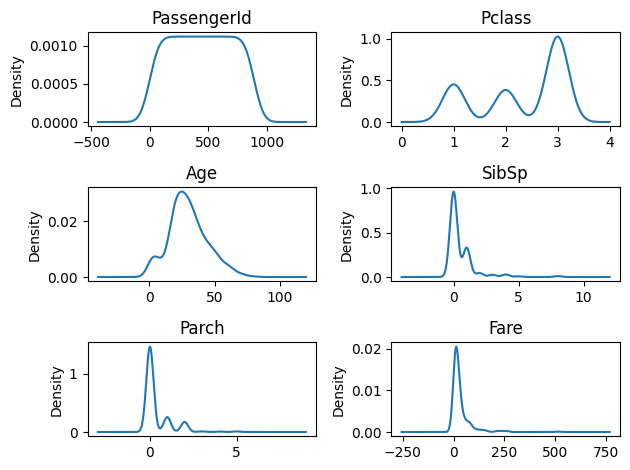

In [4]:
column_list = df.columns

fig, axes = plt.subplots(nrows = 3, ncols = 2)

count = 0;
for index in range(0,3):
    for column in range(0,2):
        if(count >= len(column_list)):
            break;
        df[column_list[count]].plot(kind = 'density', ax = axes[index][column]);
        axes[index][column].set_title(column_list[count]);
        count += 1;

plt.tight_layout()

## After Function Transformer

In [5]:
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.compose import ColumnTransformer;

In [6]:
transformer = ColumnTransformer([
    ('trf1', FunctionTransformer(np.log1p,  feature_names_out='one-to-one'), ['SibSp', 'Parch', 'Fare'])
], remainder='passthrough');

df_transformed = transformer.fit_transform(df);
df_transformed = pd.DataFrame(df_transformed, columns = transformer.get_feature_names_out())
df_transformed

,trf1__SibSp,trf1__Parch,trf1__Fare,remainder__PassengerId,remainder__Pclass,remainder__Age
0,0.693147,0.000000,2.110213,1.0,3.0,22.0
1,0.693147,0.000000,4.280593,2.0,1.0,38.0
2,0.000000,0.000000,2.188856,3.0,3.0,26.0
3,0.693147,0.000000,3.990834,4.0,1.0,35.0
4,0.000000,0.000000,2.202765,5.0,3.0,35.0
...,...,...,...,...,...,...
886,0.000000,0.000000,2.639057,887.0,2.0,27.0
887,0.000000,0.000000,3.433987,888.0,1.0,19.0
888,0.693147,1.098612,3.196630,889.0,3.0,NaN
889,0.000000,0.000000,3.433987,890.0,1.0,26.0


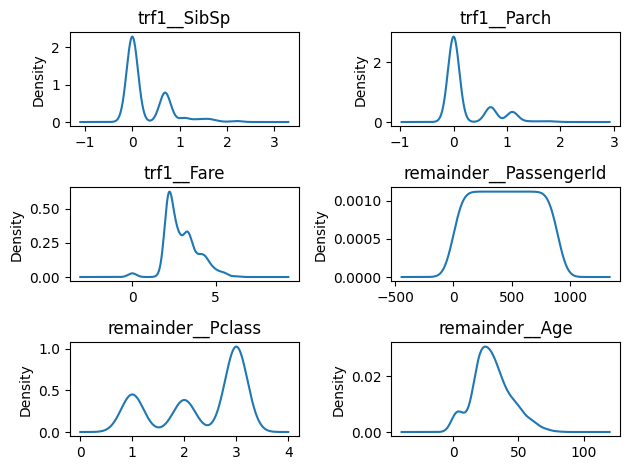

In [7]:
column_list = df_transformed.columns

fig, axes = plt.subplots(nrows = 3, ncols = 2)

count = 0;
for index in range(0,3):
    for column in range(0,2):
        if(count >= len(column_list)):
            break;
        df_transformed[column_list[count]].plot(kind = 'density', ax = axes[index][column]);
        axes[index][column].set_title(column_list[count]);
        count += 1;

plt.tight_layout()

## After Power Transformation

In [8]:
transformer = ColumnTransformer([
    ('trf1', PowerTransformer(), ['SibSp', 'Parch', 'Fare'])
], remainder='passthrough');

df_transformed = transformer.fit_transform(df);
df_transformed = pd.DataFrame(df_transformed, columns = transformer.get_feature_names_out())
df_transformed

,trf1__SibSp,trf1__Parch,trf1__Fare,remainder__PassengerId,remainder__Pclass,remainder__Age
0,1.373636,-0.560253,-0.878820,1.0,3.0,22.0
1,1.373636,-0.560253,1.336651,2.0,1.0,38.0
2,-0.679850,-0.560253,-0.790065,3.0,3.0,26.0
3,1.373636,-0.560253,1.067352,4.0,1.0,35.0
4,-0.679850,-0.560253,-0.774439,5.0,3.0,35.0
...,...,...,...,...,...,...
886,-0.679850,-0.560253,-0.294907,887.0,2.0,27.0
887,-0.679850,-0.560253,0.527906,888.0,1.0,19.0
888,1.373636,1.846856,0.288885,889.0,3.0,NaN
889,-0.679850,-0.560253,0.527906,890.0,1.0,26.0


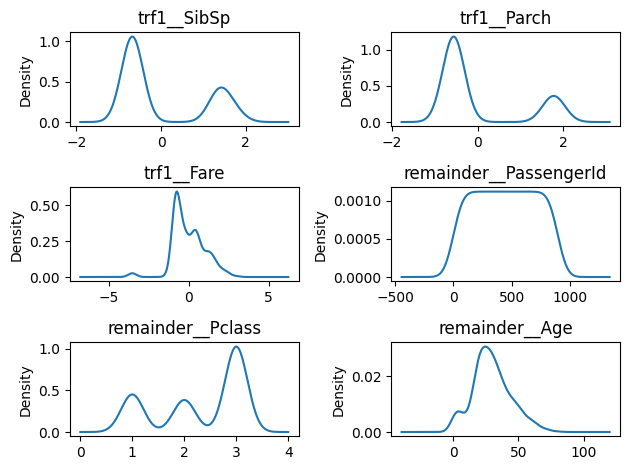

In [9]:
column_list = df_transformed.columns

fig, axes = plt.subplots(nrows = 3, ncols = 2)

count = 0;
for index in range(0,3):
    for column in range(0,2):
        if(count >= len(column_list)):
            break;
        df_transformed[column_list[count]].plot(kind = 'density', ax = axes[index][column]);
        axes[index][column].set_title(column_list[count]);
        count += 1;

plt.tight_layout()